# Explainability

### What is explainability?

Explainability tries to "bridge the gap" between the way the model works and a person’s intuition and understanding. In practice, most of the explainability methods try to “explain” the model’s output so it will be understandable by humans.
There are several reasons why explainability is important: it can increase the trust in the model’s decisions (especially in critical domains like health), it could reveal leakages, biases and unfair desicions, and it may help researchers to improve the model by better understanding of the model’s behavior. These needs become more crucial in "black box" models, like neural networks.
 There are a lot of explainability methods (XAI – eXplainability AI), maybe you already saw some of them (LIME, for example). The explanation approaches vary widely, some of them focus on the input features (SHAP), some focus on the analysis of filters and parts of the model (such as [circuit analysis](https://distill.pub/2020/circuits/)) and others focus on the output alone (LIME). While some of the explanantions are "global" - i.e. suitable for all the input space, others are "local" and only apply to part of the space. Different methods are used for different explainability needs.
 
 Some examples for relevant questions that researchers or users may ask, and XAI should supply the answers for, are: how does the input affect the output? Why did the model output this class? What will happen if we will change some features? What is the connection between a group of features? How the features influence the training process and the different parts of the model (like specific filters in neural network)? How is this sample different from other samples? etc.  
 
 In this excercise we will focus on one approach called SHAP, which used the shapley values principle from game theory for evaluating the contribution of each input feature to the output, with relation to all other features.
 
We recommend that you read more about the SHAP [library](https://github.com/slundberg/shap), and about the SHAP [method](https://arxiv.org/abs/1705.07874).


### Let's start

#### Important Notes: 
1. Solution has written with shap version 0.32.0. We are recommand to work with new version 0.39.0.
2. Older versions' API supposed to be supported also by the newer versions.
3. Main difference in the new version is the new shap.plots module. There are some same functions that can be performed from this module or by other modules.

In [32]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import shap

# load JS visualization code to notebook
shap.initjs()

Here is a toy dataset, it contains 2 binary features. we have 2 different target columns. Verify that you understand how the target is defined. Try to think (on paper...) about a decision tree with depth 2, which classifies the train samples perfectly.

In [33]:
np.random.seed(4535)
X = pd.DataFrame({'cough':np.random.randint(0, 2, 1000), 'fever': np.random.randint(0, 2, 1000)})

y_1 = X.apply(lambda x: 8*(x.cough & x.fever), axis=1)
y_2 = X.apply(lambda x: 8*(x.cough & x.fever) + 1*x.cough, axis=1)

### T1:
Train a *simple* decision tree Regressor model for each target, and plot the trees with the plot_tree function. If the first split of tree_1 (the tree trained on y_1 as a target) isn't based on the fever feature - repeat the training until the first split will be fever.

Tree 1


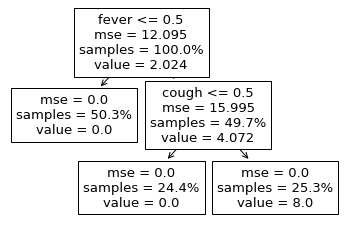

Tree 2


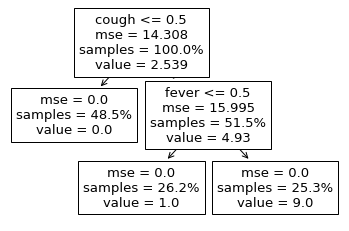

In [34]:
model_1 = DecisionTreeRegressor(random_state=4535)
model_2 = DecisionTreeRegressor(random_state=4535)

model_1.fit(X, y_1)
model_2.fit(X, y_2)

print('Tree 1')
plot_tree(model_1, feature_names=X.columns, proportion=True)
plt.show()

print('Tree 2')
plot_tree(model_2, feature_names=X.columns, proportion=True)
plt.show()

Now plot the feature importance of each of your 2 models, based gain score

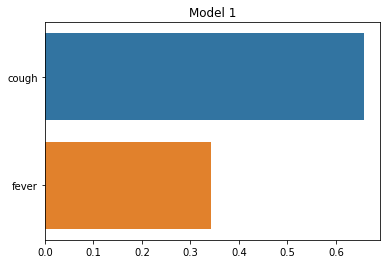

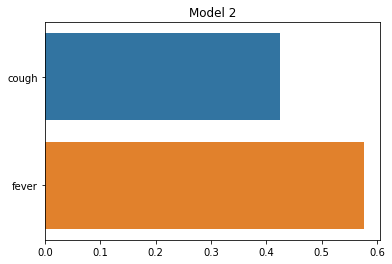

In [35]:
sns.barplot(x=model_1.feature_importances_, y=X.columns),
plt.title('Model 1')
plt.show()
sns.barplot(x=model_2.feature_importances_, y=X.columns),
plt.title('Model 2')
plt.show()

### Q1:
1. What do you see? how has the importance changed from tree1 to tree2? Does it make a sense to you? 

2. Based on the results you have seen, what does the feature importance express (and what not)? Discuss this with your instructor. 

### A1:
We see that *cough* has less importance in y_2 than *fever*, whereas in y_1 *cough* gets an  importantance score higher than *fever*. Although the y_2 target gives more weight to the *cough* feature (compared to the *fever* feature and especially compared to the weighting in y_1), the feature importance indicates a decrease in the importance of this feature in y_2. 

The reason for this is that *feature importance* is a calculation of the gain function, that takes into account information changes with every split, and not numerical evaluation of the target value. Therefore, there is no importance to the absolute changing in the target value. The only difference is the separation of the groups with *cough* and without *fever*, where in y_1 is equal to the group with neither *fever* nor *cough* and in y_2 is not equal to this group.
This is exact in Classification trees. In Regression trees, it's rather same: the gain calculated as the split that leads to the minimal variance in every child-node. So it's less important what is the specific target, the more important thing is the variance of the different samples' target.


### T2:
Now, we're going to see the SHAP method. Use the TreeExplainer method (see: https://github.com/slundberg/shap), and
plot the shap values of the 2 models (use the summary_plot function or shap.plots.bar function). Has something changed compared to feature importance computed above?

In [36]:
explainer_1 = shap.TreeExplainer(model_1)
explainer_2 = shap.TreeExplainer(model_2)

shap_vals_1 = explainer_1.shap_values(X)
shap_vals_2 = explainer_2.shap_values(X)

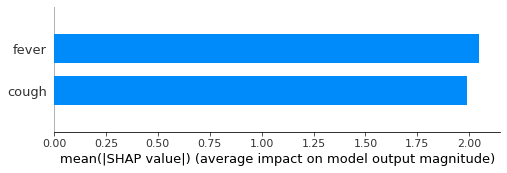

In [8]:
shap.summary_plot(shap_vals_1, plot_type='bar', features=X.columns)

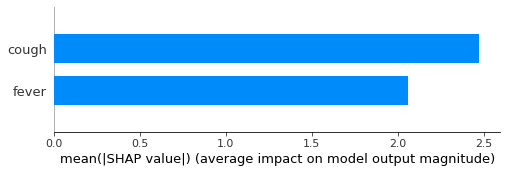

In [9]:
shap.summary_plot(shap_vals_2, plot_type='bar', features=X.columns)

### Q2:

Read about the meaning of shap values.
- How can you explain the the difference in the models' shap values?
- Is it better or worse than feature importance's explanation?
- Bonus: Notice the realtion between the 2 average SHAP values, what is the connection to the way that the dataset was created? (hint: notice the exact numbers in the creation of the dataset and the exact SHAP values). Bonus 2: you can change the dataset and examine how it's affects the SHAP values)?

### A2:
We can see that in y_1 SHAP assigns both features the same importance. However, in the y_2 model, the *cough* got more importance than *fever* by a big margin. This corresponds to the function that created the target.
The reason is that the SHAP method evaluates the numerical contribution of the features to the target, therefore an increase in the target as function of a specific feature value leads to a higher shap value. SHAP doesn’t measure the gain in the different splits (of course there might be some connection between the gain and the changes in the target value).
This is better than 'gain-based feature importance' in the aspect of the numerical value of target. But not necessarily in other aspects of the understanding of the target.
In the next sections we will see some problems with SHAP, like the fact that "importance" of a feature does not neccesarily have to be defined as the contribution to numeric target with regards to all feature combinations. sometimes we just want to see how the missing feature influences the model.

#### 'force_plot' or 'waterfall'  or 'force' plots

force_plot is a visualization for SHAP values, for a single sample or for multiple samples

### T2:
use 'force_plot' or 'waterfall' for all kinds of samples (4 optional combinations of features) in the y_2 model.

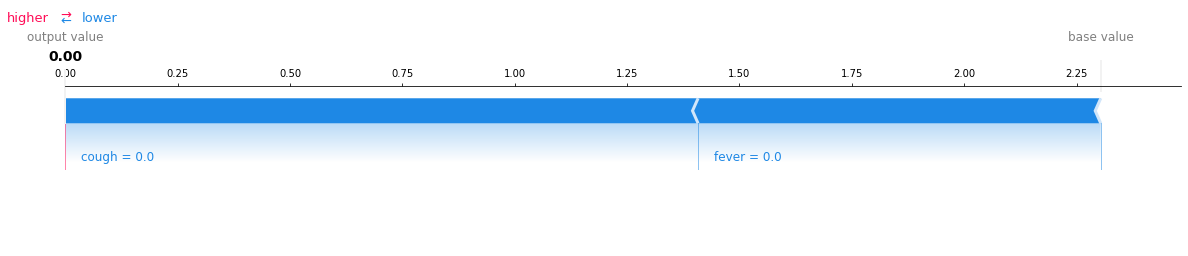

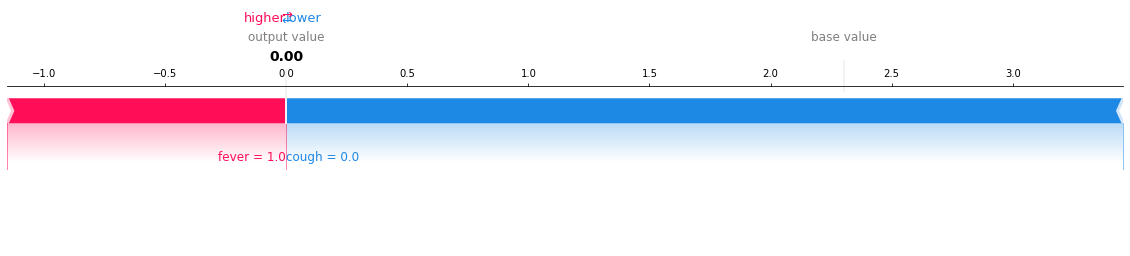

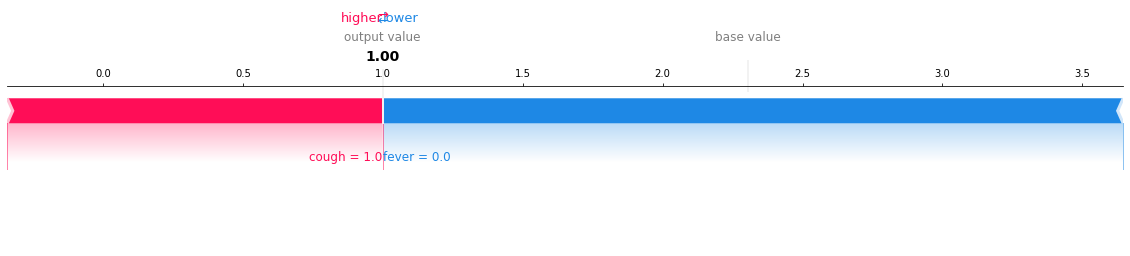

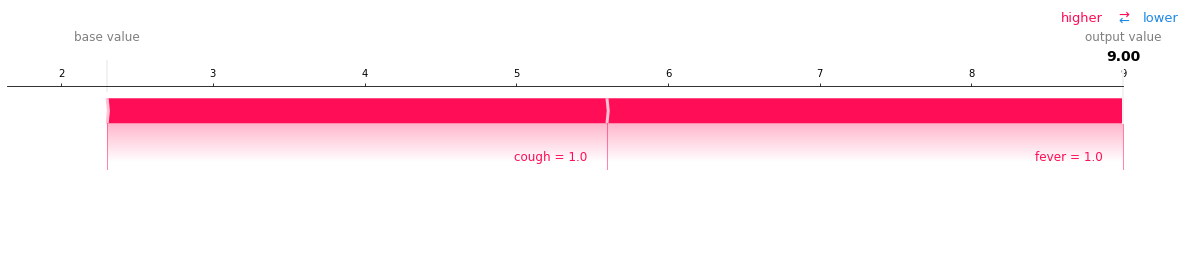

In [320]:
for i in [0,1,3,4]:
    shap.force_plot(base_value=explainer_2.expected_value, shap_values=shap_vals_2[i], feature_names=X.columns,
                    features=X.loc[i], show=True, matplotlib=True)

In the future we will see how to plot all samples together

## SHAP explainers

The SHAP method is an approximation for shapley values. This approximation has some variations. You already used the TreeExplainer variation suitable for decision trees. In the next stage we will also see some other variations

#### Tree Explainer
A very fast explainer for models based on decision trees, which calculates the exact SHAP values.

### T3:

```Use the built-in adult tabular dataset from shap.datasets. This dataset contains people's properties and the target is classification task of their income (larger than some amount or not)
Split it to train and test, and then train an XGBoost classifier. Then, use TreeExplainer for explaining your model.
Finally, use the summary_plot with plot_type='bar' and plot the 'feature importance' of XGBoost, based gain score (just like in the previous dataset). Compare them.
Note: in the new API you can use the TreeExplainer and the above plot in anouther way```

In [3]:
def performances(X, y, model, title=None):
    '''performances displaying'''
    pred = model.predict(X)
    pred_proba = model.predict_proba(X)

    if title is not None:
        print(title)
    print('ACC: ', accuracy_score(y, pred))
    print('AUC: ', roc_auc_score(y, pred_proba[:,1]))
    print(confusion_matrix(y, pred))

In [4]:
X,y = shap.datasets.adult()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [4]:
model = XGBClassifier(n_estimators=300, max_depth=12)
model.fit(X_train, y_train)

performances(X_test, y_test, model)

ACC:  0.8657999795270754
AUC:  0.9206405974255548
[[6903  494]
 [ 817 1555]]


In [6]:
%%time
tree_explainer = shap.TreeExplainer(model)
shap_vals_tree = tree_explainer.shap_values(X_test)

Wall time: 2min 9s


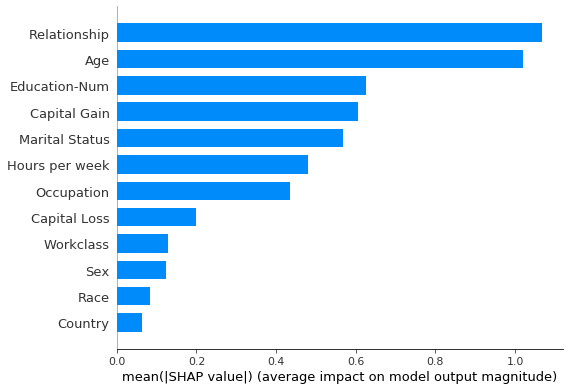

In [6]:
shap.summary_plot(shap_vals_tree, plot_type='bar', features=X_test.columns)

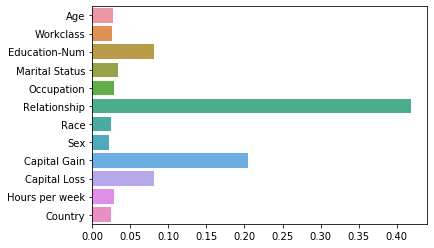

In [7]:
sns.barplot(model.feature_importances_, X_train.columns),
plt.show()

### Q3, T4:
```Are the most imporatnt features same in the 2 methods (SHAP and regular  gain-based feature_importance)? if not, what is the most important feature that the 2 methods are not agree about it?
(supposed to be the 2nd feature)```

```Now, try to train same models from scratch, once without the not-same most important feature according to SHAP and then without the not-same most important feature according to feature_importance.
Which model is better? (you can also try to use the old model, but replace the above mentioned feature values in test set with the mean of of this feature in the train, etc.)
Does this make a sense? Explain how this matches the way both methods work.```

Train the model without the specific features:

In [24]:
shap_2d_feature = 'Age'
X_train_drop1 = X_train.drop(columns=[shap_2d_feature])
X_test_drop1 = X_test.drop(columns=[shap_2d_feature])

model = XGBClassifier(n_estimators=300, max_depth=12)
model.fit(X_train_drop1, y_train)

pred = model.predict(X_test_drop1)
pred_proba = model.predict_proba(X_test_drop1)

performances(X_test_drop1, y_test, model)

ACC:  0.86539052103593
AUC:  0.9127810347863781
[[6943  503]
 [ 812 1511]]


In [28]:
fi_2d_feature = 'Capital Gain'
X_train_drop2 = X_train.drop(columns=[fi_2d_feature])
X_test_drop2 = X_test.drop(columns=[fi_2d_feature])

model_2 = XGBClassifier(n_estimators=300, max_depth=12)
model_2.fit(X_train_drop2, y_train)

pred = model_2.predict(X_test_drop2)
pred_proba = model_2.predict_proba(X_test_drop2)

performances(X_test_drop2, y_test, model_2)

ACC:  0.8416419285494933
AUC:  0.8899419774160438
[[6759  687]
 [ 860 1463]]


Replace specific feature with its mean:

In [11]:
X_test_copy = X_test.copy()
X_test_copy['Age'] = np.mean(X_train['Age'])
performances(X_test_copy, y_test, model)

ACC:  0.8595557375371071
AUC:  0.9117239316517954
[[6810  587]
 [ 785 1587]]


In [12]:
X_test_copy = X_test.copy()
X_test_copy['Capital Gain'] = np.mean(X_train['Capital Gain'])
performances(X_test_copy, y_test, model)

ACC:  0.7760262053434334
AUC:  0.8786315768595855
[[7394    3]
 [2185  187]]


### A3:
```We got that the 2nd feature of feature_importance indeed affects the model performance more than SHAP's 2nd feature (where we remove that feature or replace it with the mean value).
The reason is that SHAP expresses how the feature is important to the target related to **all** the combinations of features, it does not expresses its importance when all other features are present. In this case feature_importance does a better job, because it expresses how much that feature is useful for the model in the current status of the current features (therefore, how the performance will suffer without the feature)```

#### DeepExplainer
Deep Explainer is a SHAP method suitable for deep neural networks. This exploits the NN structure (the recursive property of the propogation in NN) for efficient and fast approximation of SHAP values. The method is the same as [DeepLIFT](https://arxiv.org/abs/1704.02685). You can read more in the SHAP [paper](https://arxiv.org/abs/1705.07874).

### T5:

- Here is a CNN for the regular MNIST classification task. Run the next cell for train the model.
- choose ~100 samples for background and use Deep Explainer for explaining some test samples (at least 10 different digits). 
  NOTICE: you should use TensorFlow 1 if you are using keras (but you can also try using tf2). You can also use pytorch.
- Use shap.image_plot for visualizing the explanations.

**NOTE** : This plot explains how every sample belongs (or not) to all possible classes. In every column (each column expresses a certain class) the plot explains how evey pixel value supports (red - high SHAP value) or contradicts (blue - low SHAP value) the claim that the sample belongs to this class. For example, pixel=1 that is colored with red in the first column means that it supports the claim that the digit is zero. If the pixel=0 it's support that the absence of the pixel supports this claim. In the same manner, blue colored pixel contradicts the claim that this image is zero.

In [22]:
# run this cell
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Dropout, Flatten, Input
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

# input image dimensions
img_rows, img_cols = 28, 28
num_classes = 10

# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


ipt = Input(input_shape)
x = Conv2D(32, kernel_size=(3, 3), activation='relu')(ipt)#, input_shape=input_shape)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

cnn = Model(ipt,output)
cnn.compile(loss=keras.losses.categorical_crossentropy, optimizer='Adam', metrics=['accuracy'])
cnn.fit(x_train, y_train, batch_size=128, epochs=2, validation_data=(x_test, y_test), verbose=2)

60000 train samples
10000 test samples
Train on 60000 samples, validate on 10000 samples
Epoch 1/2
 - 45s - loss: 0.1676 - accuracy: 0.9503 - val_loss: 0.0505 - val_accuracy: 0.9831
Epoch 2/2
 - 45s - loss: 0.0436 - accuracy: 0.9866 - val_loss: 0.0352 - val_accuracy: 0.9883


In [29]:
background = x_train[np.random.choice(x_train.shape[0], 100, replace=False)]

# explain predictions of the model on some images
deep_explainer = shap.DeepExplainer(model=cnn, data=background)#, session=tf.compat.v1.Session())
n_smaples_to_explain = 20
shap_values = deep_explainer.shap_values(x_test[:n_smaples_to_explain])

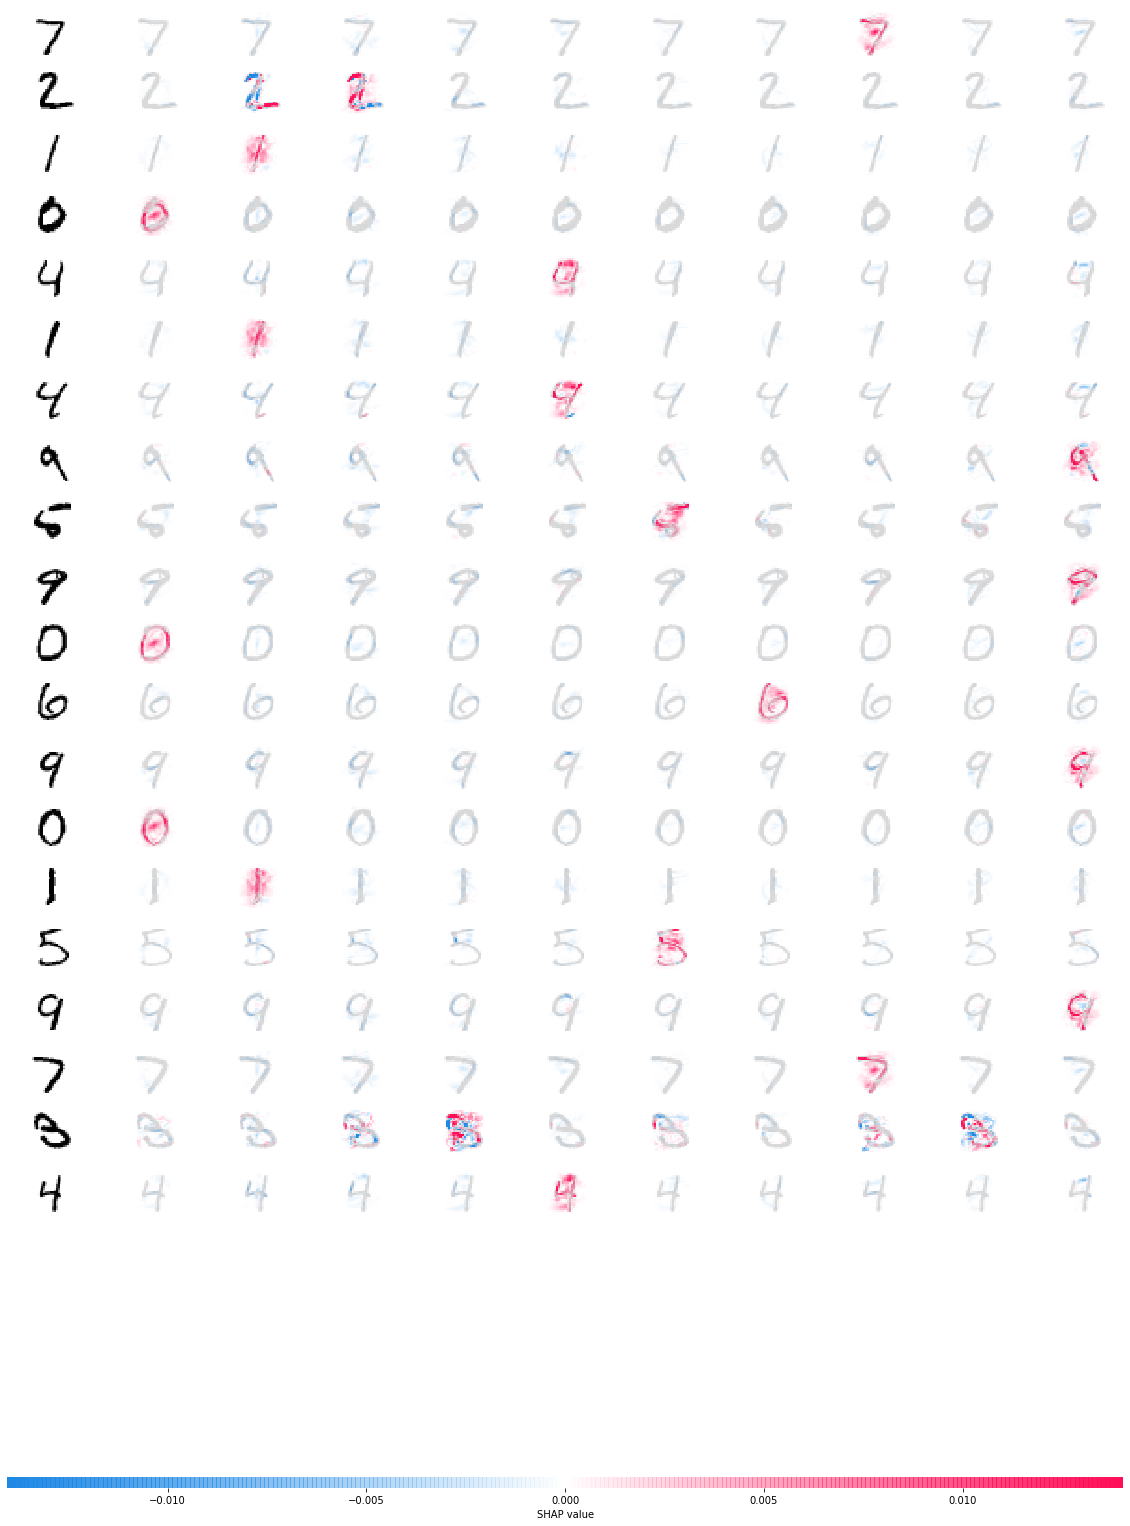

In [30]:
# plot the feature attributions
shap.image_plot(shap_values, -x_test[:n_smaples_to_explain])

### Q4:
Are the explanations convincing? Does the model utilise the important parts in the images? Do all the images in every row have colored pixels? If not, which images are colored? Discuss this with your tutor. (note that a high shap value contributes to the "positive" class and a low shap value contributes to the opposite class).

### A4:
In every row we can see the in the column of the correct label and sometimes in the columns of wrong labels (usually the columns that match to the most similar digits) the pixels that support and contradict that label. For example, the explanation for digit '4' in the 5th column (i.e., label 4) is colored with red (positive shap values) in the upper part. This means that fact the pixels in this part are missing supports the label "4" (by contradicting the label of "9"). In the 10th column (i.e. label "9") this upper part colored with blue (negative shap), meaning the fact that these pixels are missing contradicts the "9" label.

### Bonus:
If you want you can apply other methods (such as LIME) on MNIST and compare the different explanations.

#### KernelExplainer
An exteremly slow method for calculating the SHAP values of every model - every blackbox. The method evaluates the SHAP values by access to the model's input and output only, with no knoweldge of the model structure. The evaluating is performed by averaging over a lot of random combinations of inputs with "missing" features and measuring the effects of every missing combination on the target.

### T6:

Choose any model you want (NN, Tree, NaiveBayes etc.) and train it on the MNIST dataset.
Now, try to explain it with KernelExplainer. For shorter runtime you can limit the 'nsamples' variable, but it might affects the explanation quality.

In addition, try using KernelExplainer for the CNN from the previous section. change the nsamples parametrs and examine how it's influence the performances.

In [4]:
from sklearn.naive_bayes import GaussianNB

x_train_reshaped = x_train.reshape((x_train.shape[0],-1))
x_test_reshaped = x_test.reshape((x_test.shape[0],-1))
y_train_cat = y_train.argmax(1)
y_test_cat = y_test.argmax(1)

gnb = GaussianNB()
gnb.fit(x_train_reshaped, y_train_cat)

In [68]:
print('Train Acc: ', accuracy_score(y_train_cat, gnb.predict(x_train_reshaped)))
print('Test Acc: ', accuracy_score(y_test_cat, gnb.predict(x_test_reshaped)))

Train Acc:  0.5649
Test Acc:  0.5558


In [5]:
background_reshaped = background.reshape((background.shape[0],-1))

def gnb_predict(X):
    return gnb.predict(X)
kernel_explainer = shap.KernelExplainer(gnb_predict, background_reshaped)

shap_values = kernel_explainer.shap_values(x_test_reshaped[:7], nsamples=1000)

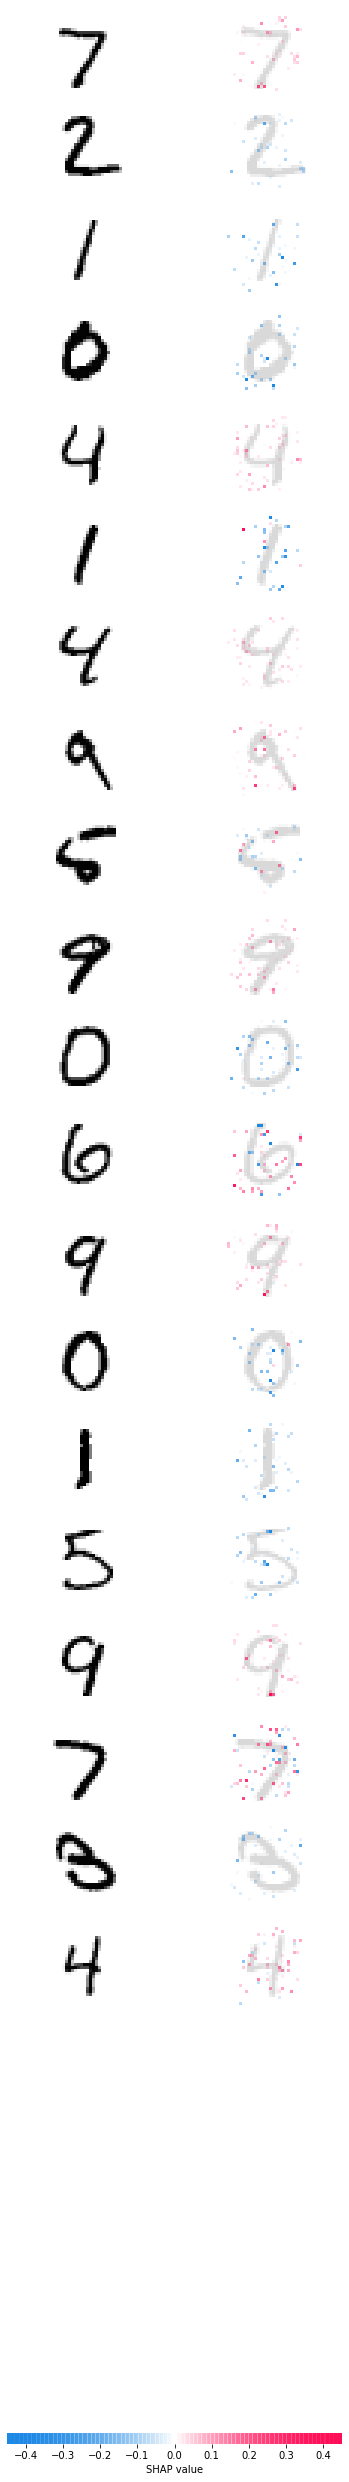

In [76]:
# plot the feature attributions
shap.image_plot(shap_values.reshape(shap_values.shape[0], 28,28,1), -x_test[:shap_values.shape[0]])

CNN from the previous section:

In [55]:
def cnn_predict(X):
    X_image = X.reshape(X.shape[0], 28,28,1)
    return cnn.predict(X_image)
kernel_explainer = shap.KernelExplainer(cnn_predict, background_reshaped)

n_samples_to_explain = 4
shap_values = kernel_explainer.shap_values(x_test_reshaped[:n_samples_to_explain], nsamples='auto')

shap_values_for_kernel_reshaped = [val.reshape(val.shape[0],28,28,1) for val in shap_values]

In [79]:
shap_values_for_kernel_reshaped = [val.reshape(val.shape[0],28,28,1) for val in shap_values]

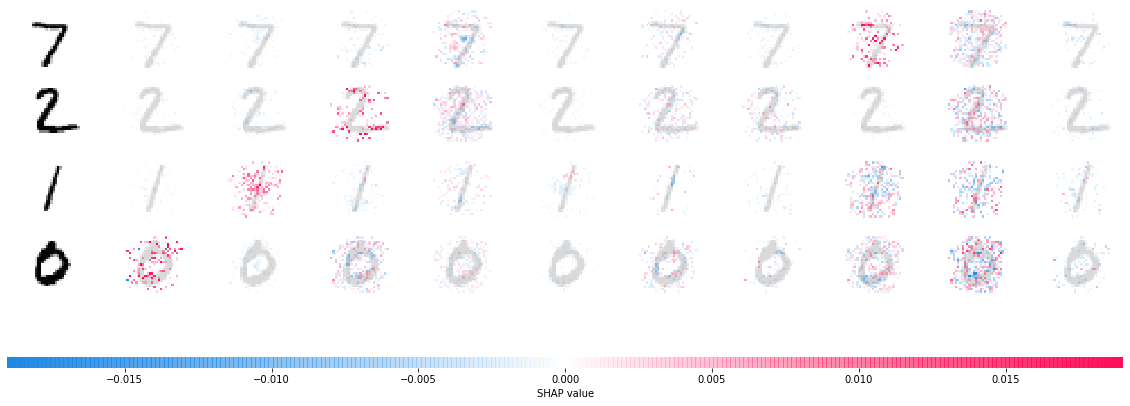

In [80]:
# plot the feature attributions - nsamples='auto'
shap.image_plot(shap_values_for_kernel_reshaped, -x_test[:n_samples_to_explain])

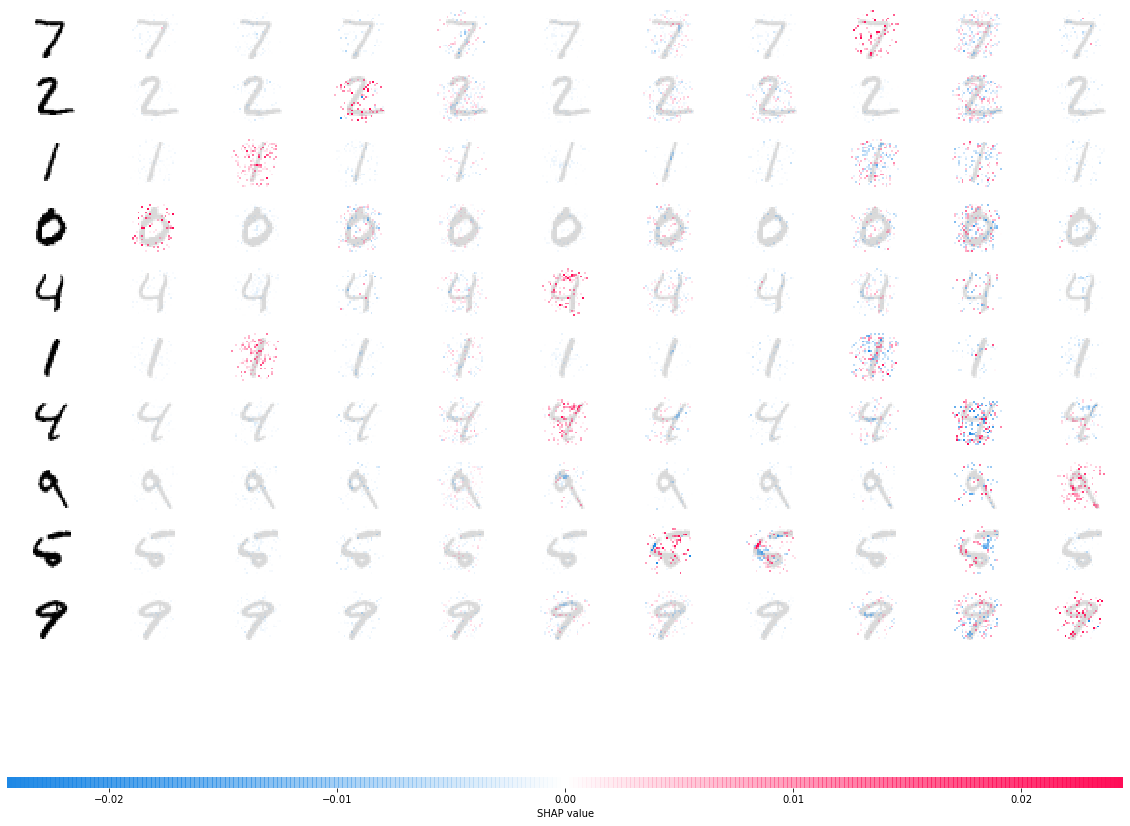

In [59]:
# plot the feature attributions - nsamples=1500
shap.image_plot(shap_values_for_kernel_reshaped, -x_test[:n_samples_to_explain])

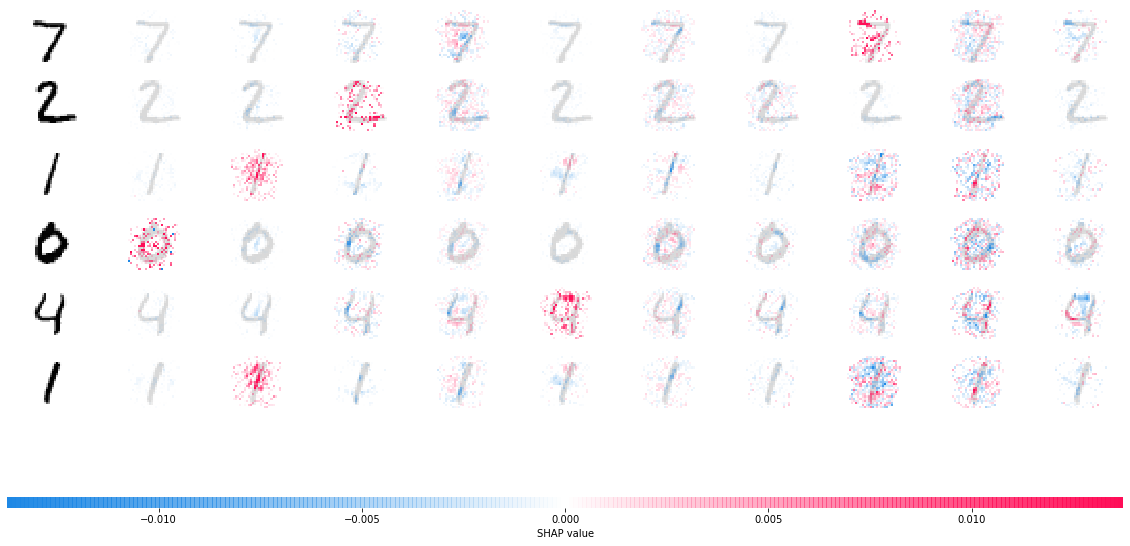

In [87]:
# plot the feature attributions - nsamples=10000
shap.image_plot(shap_values_for_kernel_reshaped, -x_test[:n_samples_to_explain])

### Q5:
What do you think about these explanations, are they good enough? Compare these explanations with the DeepSHAP results.

### A5:
The explanantions do not look good when nsamples is low. With big nsamples this starts to look better and we can start to understand which features are more important and make sense of it. For example, the top part of 4 and 9 are marked with high SHAP value, because this is important for telling these features apart. With the high nsamples values its become clearer.
DeepSHAP is clearer and has less noise (random red/blue points) compared to KernelSHAP.

### Bonus: 
If you want, you can try using more kinds of Explainers in the SHAP package (Gradient Explainer, Linear Explainer).

## Other Plots

Return to adults dataset with the models you have trained, and apply the next plots.

### T7 - global Force_plot

You already saw the force_plot in the toy dataset. Now, use the force_plot in a more complicated dataset (adults) for overall viewing of model outputs and their shap values. plot the shap values of all sampels together:

In [96]:
# visualize the training set predictions
shap.force_plot(tree_explainer.expected_value, shap_vals_tree, X_test)

C:\Users\MMM\AppData\Roaming\Python\Python37\site-packages\shap\plots\force.py:141: UserWarning: shap.force_plot is slow for many thousands of rows, try subsampling your data.
  warnings.warn("shap.force_plot is slow for many thousands of rows, try subsampling your data.")


### Q6:
What can you see in this plot? How can this plot be useful (in more complicated datasets with more features and groups of samples)? Your answer can focus on connections between features and groups of samples. (There is more than one possible answer).

### A6:
You can divide samples into groups based on their explanantions, see special or strange groups of samples with un-normal explanantions. Additionaly, you can see which features are the most important for different groups of samples. 

### T8 - global Summary_plot

use summary_plot (not with plot_type="bar". or 'beeswarm' in the new API) for overall viewing of all samples distribution in every feature:

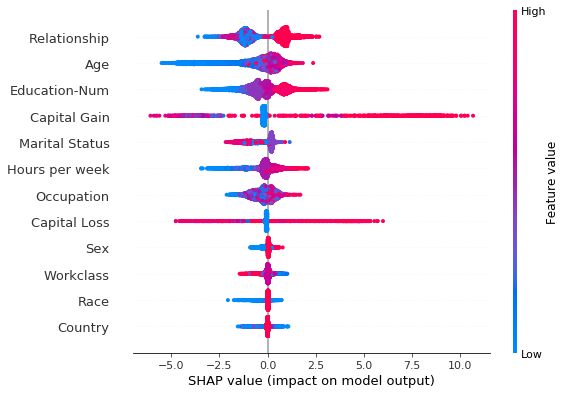

In [97]:
# summarize the effects of all the features
shap.summary_plot(shap_vals_tree, X_test)

### Q7:
1. Which insights you can get from this plot about the influence of specific features on the target? For example, explain how "Age" and "Hours per week" affect the target.
2. Which information can you get from this kind of plot that you can't get from 'feature importance' or the averaged shap version of feature importance (i.e. force_plot with plot_type="bar")?

### A7:
1. We can see that high ages contribute to high salary (positive SHAP value), but low age drastically contributes to low salary - low age has much more influence than high age. In addition, we can see that this connection between salary and age is not definitive, there are low ages with high positive SHAP values and high ages with negative SHAP values. In contrast, the features "Education Num" and "Hours per week" show more consistent behaviour: high feature values always leads to high SHAP values and vise versa.
2. This kinds of plot shows *distribution*, compared to the overall average in 'feature importance' and etc. This can reveal more exact behavior of samples, and how different ranges of the features affects the target.

#### Bonus:
You can also examine 'dependence_plot' ('scatter' in the new API) and the 'shap_interaction_values' plots, that show the higher-order interactions between different features and the target.

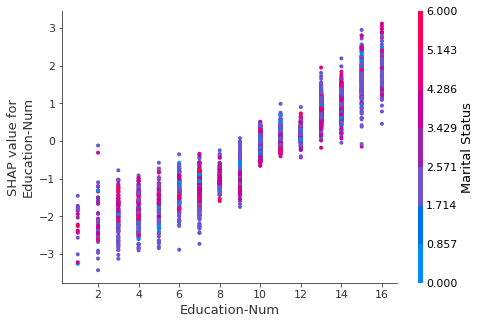

In [101]:
# create a dependence plot to show the effect of a single feature across the whole dataset
shap.dependence_plot('Education-Num', shap_vals_tree, X_test)

## Summary

1. Do you think that explainability is important and/or useful? In which cases would you use it?
2. Which tools you going to take with you for your future work? detail 1-3 tools.